# Single Pulsar NUTS Sampling with BlackJax

This notebook demonstrates Bayesian parameter inference for a single
pulsar timing model using BlackJax's NUTS (No-U-Turn Sampler).

The workflow is:
1. Load NGC6440E data and convert to JaxPINT objects
2. Run a WLS fit to get a starting point and covariance estimate
3. Define a log-probability (likelihood + Gaussian prior from WLS)
4. Run NUTS warmup and sampling via BlackJax
5. Diagnostics and comparison to WLS estimates

In [1]:
import blackjax

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## 1. Load data and convert to JaxPINT

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

## Temporarily have PINT shut up with DEBUG and INFO messages
from loguru import logger
logger.disable("pint")

from jaxpint.likelihood import single_pulsar_logL
from jaxpint.fitters import WLSFitter
from jaxpint.notebook_utils import load_example_pulsar

# Load NGC6440E and bridge to JaxPINT (PINT load + bridge conversion in one call)
psr = load_example_pulsar()
toa_data, params, timing_model, noise_model = (
    psr.toa_data, psr.params, psr.timing_model, psr.noise_model
)

print(f"Pulsar: {psr.pint_model.PSR.value}")
print(f"Free parameters: {params.free_names()}")
print(f"Number of free params: {params.n_free}")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/models/pulsar_binary.py:37: SyntaxWarning: invalid escape sequence '\s'
  """Base class for binary models in PINT.
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/models/binary_dd.py:136: SyntaxWarning: invalid escape sequence '\l'
  """Damour and Deruelle model with alternate Shapiro delay parameterization.
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/models/stand_alone_psr_binaries/DDS_model.py:11: SyntaxWarning: invalid escape sequence '\l'
  """Damour and Deruelle model with alternate Shapiro delay parameterization.
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/models/stand_alone_psr_binaries/DDK_model.py:12: SyntaxWarning: invalid escape sequence '\D'
  """DDK model, a Kopeikin method corrected DD model.
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/models/stand_alone_psr_binarie

Pulsar: 1748-2021E
Free parameters: ('RAJ', 'DECJ', 'F0', 'F1', 'DM')
Number of free params: 5


## 2. WLS fit for starting point and covariance

In [3]:
fitter = WLSFitter(timing_model, toa_data, params, noise_model=noise_model)
# JIT warmup
_ = fitter.fit_toas(maxiter=1)
# Full fit
wls_result = fitter.fit_toas(maxiter=99)

wls_params = wls_result.params
wls_free = wls_params.free_values()
wls_cov = np.array(wls_result.covariance_matrix)
wls_unc = wls_result.parameter_uncertainties

print(f"Reduced chi2: {wls_result.reduced_chi2:.4f}")
print(f"\n{'Parameter':<10} {'WLS Value':>20} {'Uncertainty':>15}")
print("-" * 45)
for name, val, err in zip(wls_params.free_names(), wls_free, wls_unc):
    print(f"{name:<10} {float(val):>20.10g} {float(err):>15.4g}")

Reduced chi2: 1.0638

Parameter             WLS Value     Uncertainty
---------------------------------------------
RAJ                 4.663868852       9.835e-09
DECJ              -0.3553169572       1.593e-07
F0                  61.48547655       1.809e-11
F1             -1.181331692e-15       1.442e-18
DM                  224.1137963         0.03494


## 3. Define log-probability in whitened coordinates

The timing parameters span ~17 orders of magnitude (F1 ~ 1e-15 vs DM ~ 224).
No single step size works for all of them. We reparametrize using the WLS
covariance Cholesky: `theta = L^{-1} (x - x_wls)`, so that in `theta`-space
all parameters are O(1) and approximately uncorrelated.

The Gaussian prior from WLS becomes a standard normal in `theta`-space.

In [4]:
# Whitening transform via WLS Cholesky
wls_cov_jax = jnp.array(wls_cov)
L = jnp.linalg.cholesky(wls_cov_jax)
L_inv = jnp.linalg.inv(L)
wls_mean = jnp.array(wls_free)

def theta_to_free(theta):
    """Map whitened coords back to physical parameter space."""
    return wls_mean + L @ theta

def free_to_theta(free_values):
    """Map physical parameters to whitened coords."""
    return L_inv @ (free_values - wls_mean)

# Log-prior in whitened space: standard normal (from the Gaussian WLS prior)
def log_prior_whitened(theta):
    return -0.5 * jnp.dot(theta, theta)

def log_prob_whitened(theta):
    """Log-posterior in whitened coordinates."""
    free_values = theta_to_free(theta)
    new_params = wls_params.with_free_values(free_values)
    ll = single_pulsar_logL(toa_data, timing_model, noise_model, new_params)
    lp = log_prior_whitened(theta)
    return ll + lp

# Test at the WLS solution (theta = 0)
theta_init = jnp.zeros(len(wls_free))

log_prob_w_jit = jax.jit(log_prob_whitened)
grad_log_prob_w_jit = jax.jit(jax.grad(log_prob_whitened))

lp_val = log_prob_w_jit(theta_init)
grad_val = grad_log_prob_w_jit(theta_init)

print(f"log P at WLS solution (theta=0): {lp_val:.4f}")
print(f"Gradient at theta=0: {grad_val}")
print(f"Any NaN gradients: {jnp.any(jnp.isnan(grad_val))}")

log P at WLS solution (theta=0): 571.5922
Gradient at theta=0: [-0.04880424  0.01956752  0.01099115 -0.01949427  0.00302741]
Any NaN gradients: False


## 4. NUTS warmup and sampling

In [5]:
# Warmup with window adaptation in whitened space
warmup = blackjax.window_adaptation(
    blackjax.nuts,
    log_prob_whitened,
    initial_step_size=1.0,
)

rng_key = jax.random.key(42)
rng_key, warmup_key = jax.random.split(rng_key)

print("Running warmup (this may take a minute for JIT compilation)...")
(state, warmup_info), _ = warmup.run(warmup_key, theta_init, num_steps=500)

print(f"Adapted step size: {warmup_info['step_size']:.6f}")
print(f"Final state log-prob: {state.logdensity:.4f}")

Running warmup (this may take a minute for JIT compilation)...
Adapted step size: 0.630473
Final state log-prob: 570.6778


In [6]:
# Build the NUTS kernel with adapted parameters
nuts_kernel = blackjax.nuts(
    log_prob_whitened,
    step_size=warmup_info["step_size"],
    inverse_mass_matrix=warmup_info["inverse_mass_matrix"],
)


def inference_step(carry, rng_key):
    state, info = nuts_kernel.step(rng_key, carry)
    return state, (state, info)


# Run sampling
n_samples = 2000
rng_key, sample_key = jax.random.split(rng_key)
sample_keys = jax.random.split(sample_key, n_samples)

print(f"Drawing {n_samples} samples...")
(final_state, (states, infos)) = jax.lax.scan(inference_step, state, sample_keys)

# Transform whitened samples back to physical space
theta_samples = states.position  # (n_samples, n_params) in whitened space
samples = jax.vmap(theta_to_free)(theta_samples)  # back to physical

acceptance_rate = float(jnp.mean(infos.acceptance_rate))
print(f"Acceptance rate: {acceptance_rate:.2%}")
print(f"Samples shape: {samples.shape}")

Drawing 2000 samples...
Acceptance rate: 92.07%
Samples shape: (2000, 5)


## 5. Diagnostics

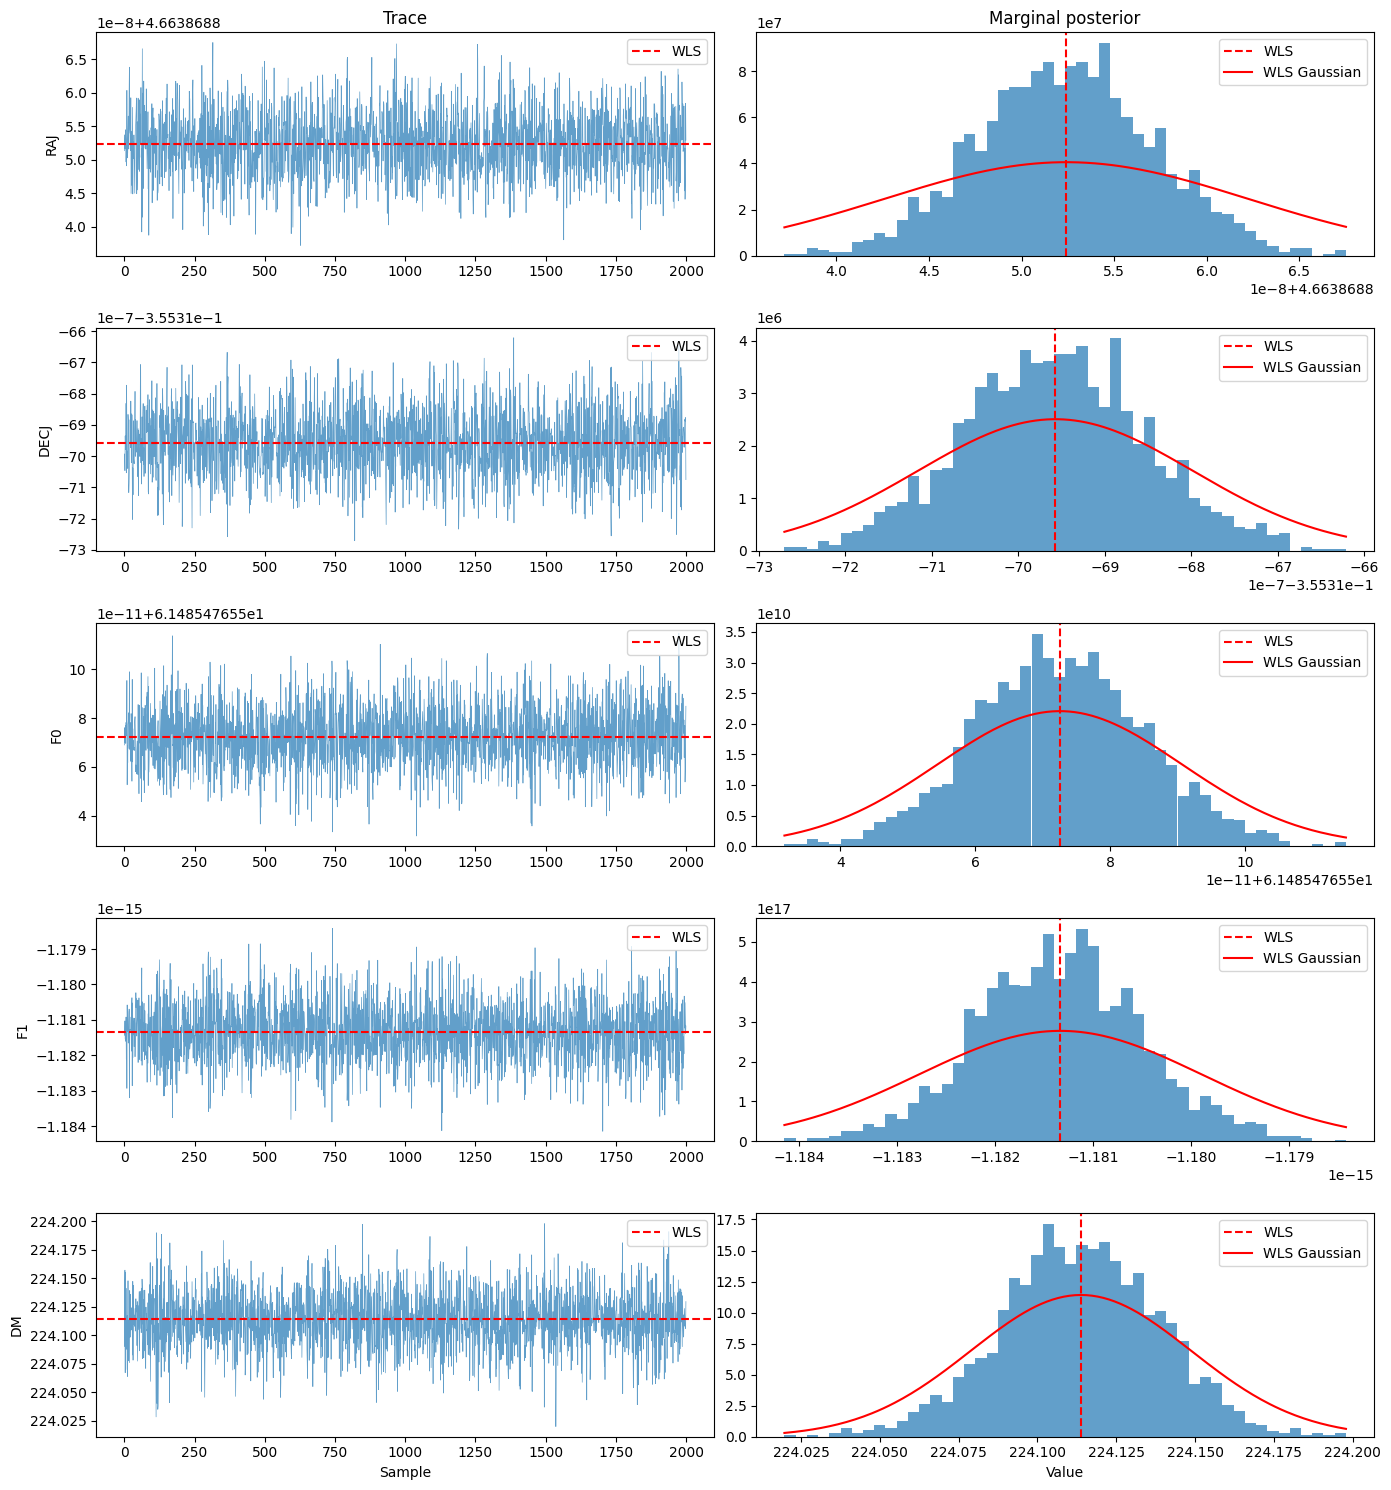

In [7]:
free_names = wls_params.free_names()
samples_np = np.array(samples)

# Trace plots
fig, axes = plt.subplots(len(free_names), 2, figsize=(14, 3 * len(free_names)))

for i, name in enumerate(free_names):
    # Trace
    axes[i, 0].plot(samples_np[:, i], alpha=0.7, linewidth=0.5)
    axes[i, 0].axhline(float(wls_free[i]), color="r", linestyle="--", label="WLS")
    axes[i, 0].set_ylabel(name)
    axes[i, 0].legend(loc="upper right")

    # Marginal histogram
    axes[i, 1].hist(samples_np[:, i], bins=50, density=True, alpha=0.7)
    axes[i, 1].axvline(float(wls_free[i]), color="r", linestyle="--", label="WLS")
    # Overlay Gaussian from WLS uncertainty
    x = np.linspace(samples_np[:, i].min(), samples_np[:, i].max(), 200)
    sigma = float(wls_unc[i])
    mu = float(wls_free[i])
    axes[i, 1].plot(x, np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)),
                    "r-", label="WLS Gaussian")
    axes[i, 1].legend(loc="upper right")

axes[0, 0].set_title("Trace")
axes[0, 1].set_title("Marginal posterior")
axes[-1, 0].set_xlabel("Sample")
axes[-1, 1].set_xlabel("Value")
plt.tight_layout()
plt.show()

In [8]:
# Compare posterior summary to WLS estimates
post_mean = np.mean(samples_np, axis=0)
post_std = np.std(samples_np, axis=0)

print(f"{'Parameter':<10} {'WLS Mean':>20} {'WLS Unc':>15} {'Post Mean':>20} {'Post Std':>15} {'Diff (sigma)':>12}")
print("-" * 93)
for i, name in enumerate(free_names):
    diff_sigma = (post_mean[i] - float(wls_free[i])) / float(wls_unc[i])
    print(f"{name:<10} {float(wls_free[i]):>20.10g} {float(wls_unc[i]):>15.4g} "
          f"{post_mean[i]:>20.10g} {post_std[i]:>15.4g} {diff_sigma:>12.2f}")

Parameter              WLS Mean         WLS Unc            Post Mean        Post Std Diff (sigma)
---------------------------------------------------------------------------------------------
RAJ                 4.663868852       9.835e-09          4.663868852       4.756e-09        -0.00
DECJ              -0.3553169572       1.593e-07        -0.3553169577       1.052e-07        -0.00
F0                  61.48547655       1.809e-11          61.48547655       1.253e-11        -0.00
F1             -1.181331692e-15       1.442e-18     -1.181346208e-15       8.484e-19        -0.01
DM                  224.1137963         0.03494          224.1133031         0.02531        -0.01


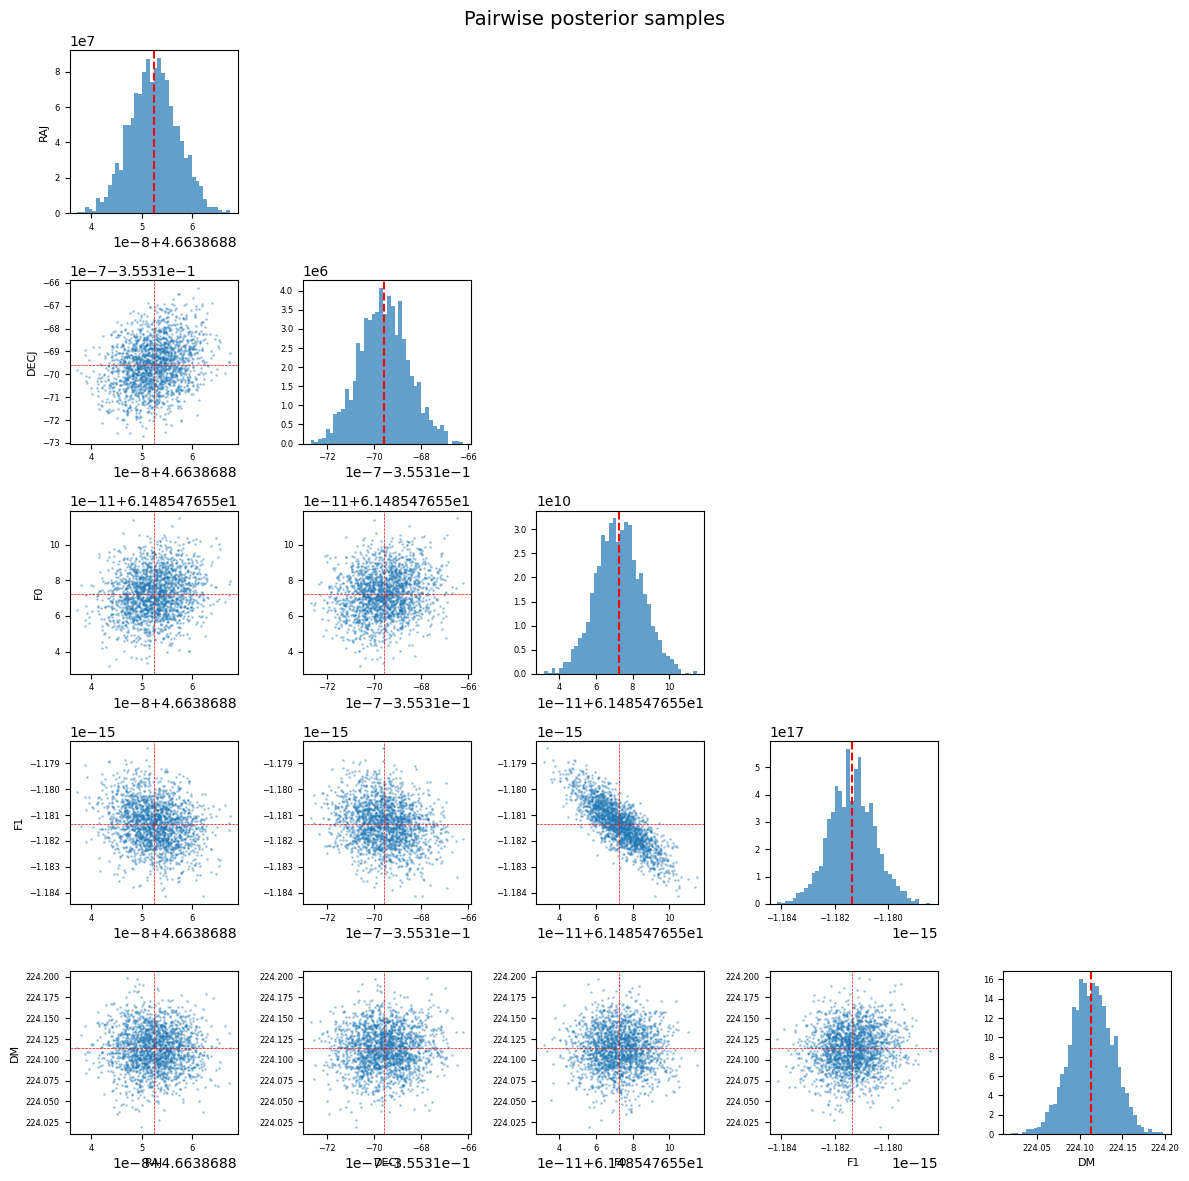

In [9]:
# Pairwise scatter (corner-style)
n_params = len(free_names)
fig, axes = plt.subplots(n_params, n_params, figsize=(12, 12))

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
        elif i == j:
            ax.hist(samples_np[:, i], bins=40, density=True, alpha=0.7)
            ax.axvline(float(wls_free[i]), color="r", linestyle="--")
        else:
            ax.scatter(samples_np[:, j], samples_np[:, i], s=1, alpha=0.3)
            ax.axhline(float(wls_free[i]), color="r", linestyle="--", linewidth=0.5)
            ax.axvline(float(wls_free[j]), color="r", linestyle="--", linewidth=0.5)

        if i == n_params - 1:
            ax.set_xlabel(free_names[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(free_names[i], fontsize=8)
        ax.tick_params(labelsize=6)

plt.suptitle("Pairwise posterior samples", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# NUTS diagnostics
print(f"Acceptance rate: {acceptance_rate:.2%}")
print(f"Mean tree depth: {np.mean(np.array(infos.num_integration_steps)):.1f}")
print(f"Max tree depth: {np.max(np.array(infos.num_integration_steps))}")

Acceptance rate: 92.07%
Mean tree depth: 6.2
Max tree depth: 15
